# Лабораторная работа 1. Линейная регрессия и факторный анализ

## Цель работы:
Изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качества.

## Датасет
**Источник:** [Boston House Price Data](https://www.kaggle.com/datasets/arunjathari/bostonhousepricedata/data)

## Описание
Этот набор данных содержит информацию о жилищном фонде в районе Бостона, штат Массачусетс, собранную Службой переписи населения США. 

**Основные характеристики:**
- Источник: StatLib archive (http://lib.stat.cmu.edu/datasets/boston)
- Широко используется для сравнительной оценки алгоритмов машинного обучения
- Объем данных: 506 наблюдений
- Количество признаков: 13 независимых переменных + 1 целевая переменная

## Описание переменных датасета

| Переменная | Описание |
|------------|-----------|
| **CRIM** | Уровень преступности на душу населения по городам |
| **ZN** | Доля жилых земель под участки более 25 000 кв. футов |
| **INDUS** | Доля нерозничной коммерческой недвижимости в акрах на город |
| **CHAS** | Фиктивная переменная реки Чарльз (1 - граничит с рекой; 0 - нет) |
| **NOX** | Концентрация оксидов азота (частей на 10 миллионов) |
| **RM** | Среднее количество комнат на жилище |
| **AGE** | Доля домов, построенных до 1940 года |
| **DIS** | Взвешенное расстояние до пяти бостонских центров занятости |
| **RAD** | Индекс доступности к радиальным магистралям |
| **TAX** | Ставка налога на имущество на $10,000 |
| **PTRATIO** | Соотношение учеников и учителей по городам |
| **B** | 1000(Bk - 0.63)², где Bk — доля чернокожего населения |
| **LSTAT** | Процент населения с низким социальным статусом |
| **MEDV** | **Медианная стоимость домов** (в тысячах долларов) |

In [8]:
#python -m pip install matplotlib pandas scikit-learn seaborn jupyter numpy ipykernel
 

In [ ]:
# # Импорт библиотек
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import skew, kurtosis, kstest

ak



# 2. Подготовка данных: первичный анализ, визуализация распределения признаков и целевой переменной

In [5]:
# Чтение данных из файла в датафрейм. Настройки
path = 'Boston-house-price-data.csv'
drop_columns = ['dteday', 'instant', 'Transaction date', 'Country or region', 'Id']
target = 'MEDV'

# Дескриптивный анализ столбцов
pd.set_option('display.float_format', '{:.2f}'.format)
df = pd.read_csv(path)
df.info()
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
        CRIM     ZN  INDUS   CHAS    NOX     RM    AGE    DIS    RAD    TAX  \
count 506.00 506.00 506.00 506.00 506.00 506.00 506.00 506.00 506.00 506.00   
mean    3.61  11.36  11.14   0.07   0.55   6.28  68.57   3.80   9.55 408.24  

### Все данные загружены. Пропущенных значений нет

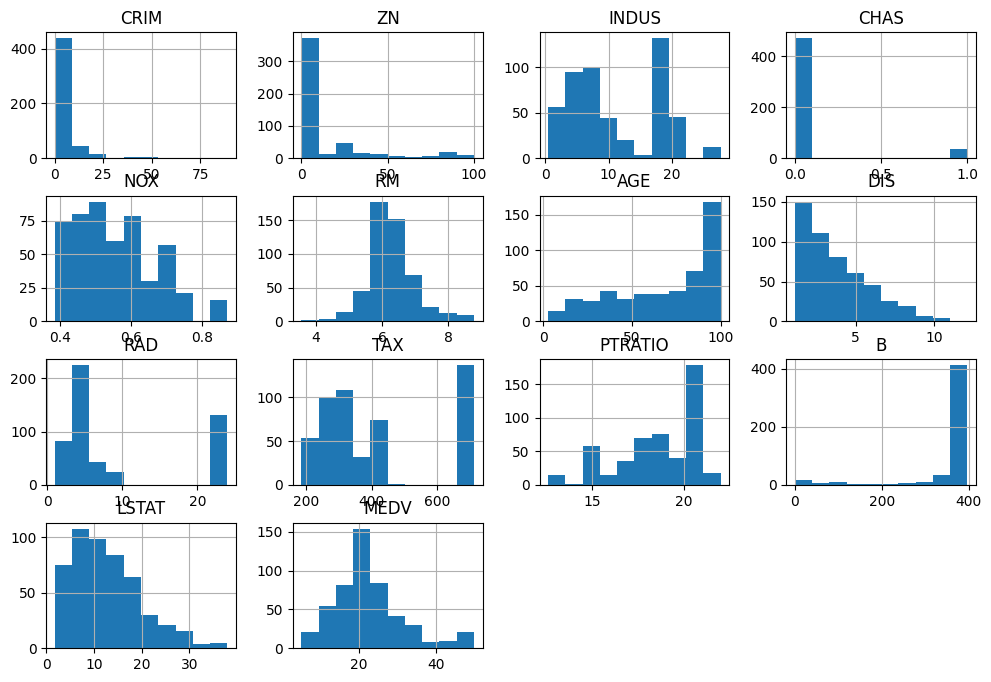

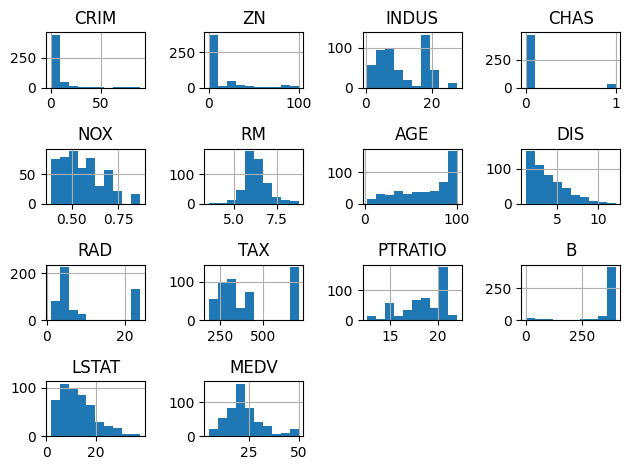

In [6]:
# Визуализация признаков и целевой переменной
df.hist(figsize=(12,8))
df.hist()
plt.tight_layout()
plt.show()

### Была произведена нормализация, т.е. приведение всех факторов к mean = 0, std = 1

CRIM
--------------------------------------------------
Ассиметрия: 5.208
Эксцесс: 36.753
Колмогорова-Смирнова p-value: 0.000
Колмогорова-Смирнова статистика: 0.337
Колмогорова-Смирнова нормальность: Нет
Уровень значимости: 0.05

ZN
--------------------------------------------------
Ассиметрия: 2.219
Эксцесс: 3.980
Колмогорова-Смирнова p-value: 0.000
Колмогорова-Смирнова статистика: 0.422
Колмогорова-Смирнова нормальность: Нет
Уровень значимости: 0.05

INDUS
--------------------------------------------------
Ассиметрия: 0.294
Эксцесс: -1.233
Колмогорова-Смирнова p-value: 0.000
Колмогорова-Смирнова статистика: 0.219
Колмогорова-Смирнова нормальность: Нет
Уровень значимости: 0.05

CHAS
--------------------------------------------------
Ассиметрия: 3.396
Эксцесс: 9.531
Колмогорова-Смирнова p-value: 0.000
Колмогорова-Смирнова статистика: 0.538
Колмогорова-Смирнова нормальность: Нет
Уровень значимости: 0.05

NOX
--------------------------------------------------
Ассиметрия: 0.727
Эксцесс: -

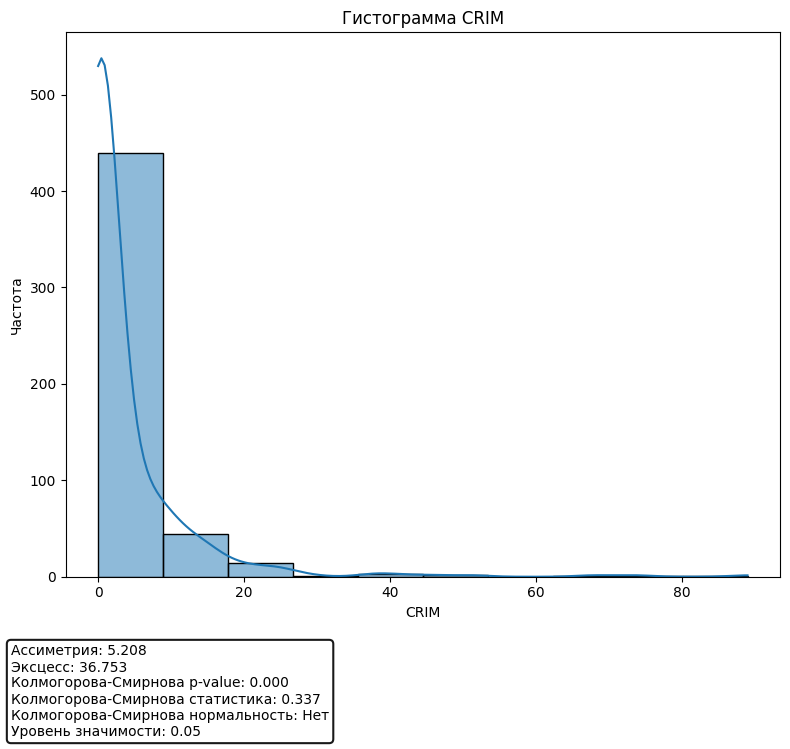

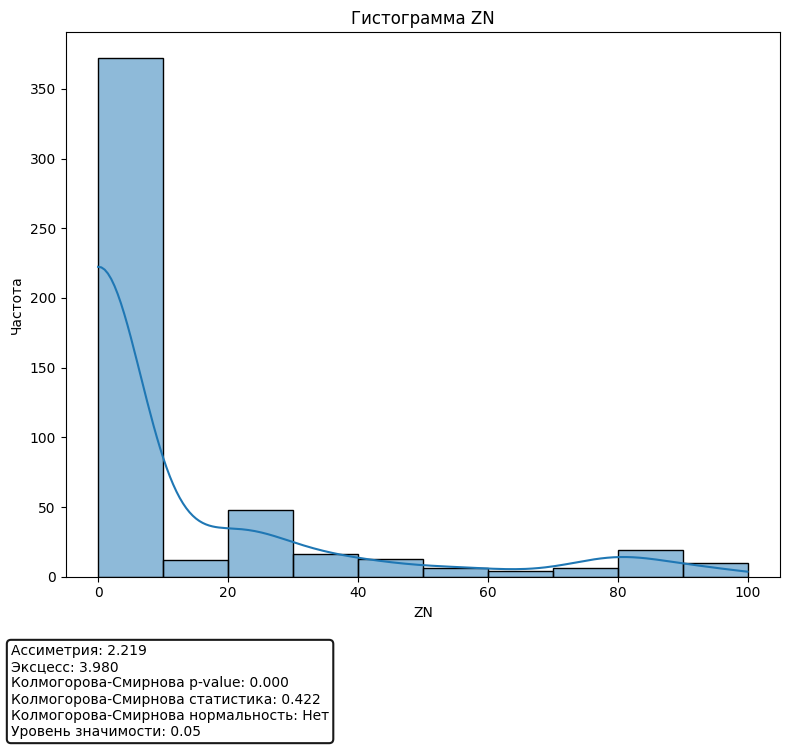

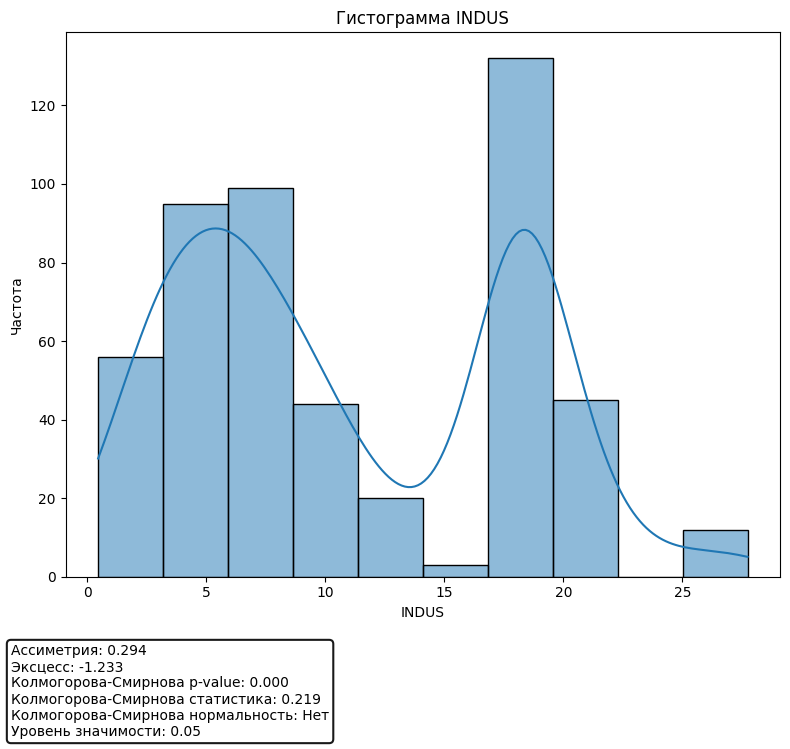

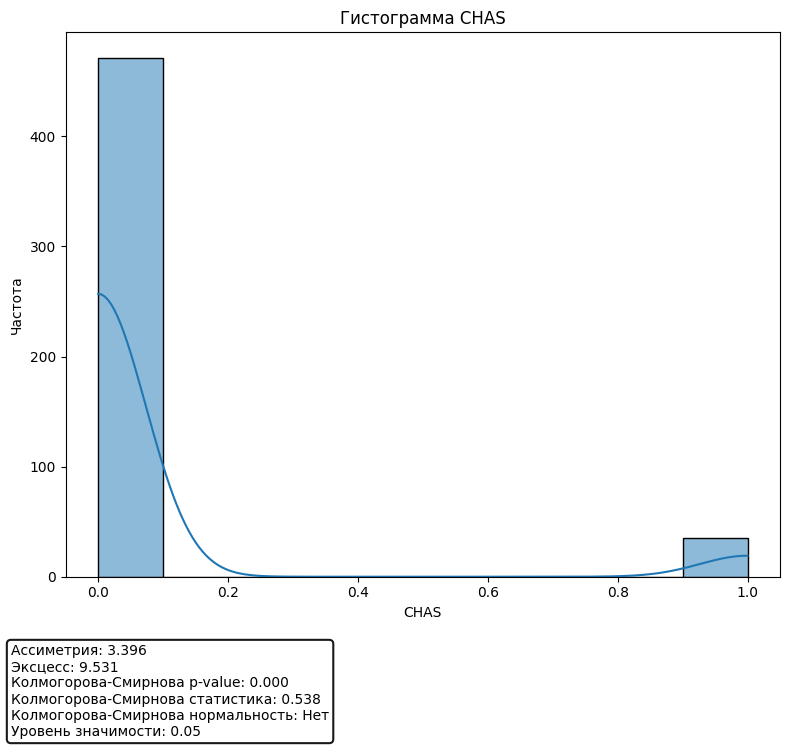

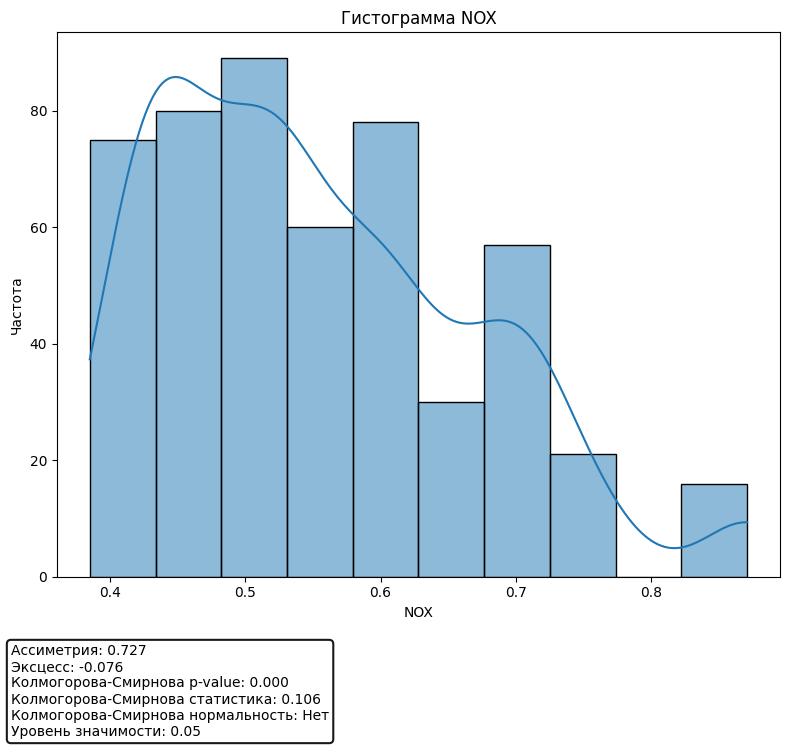

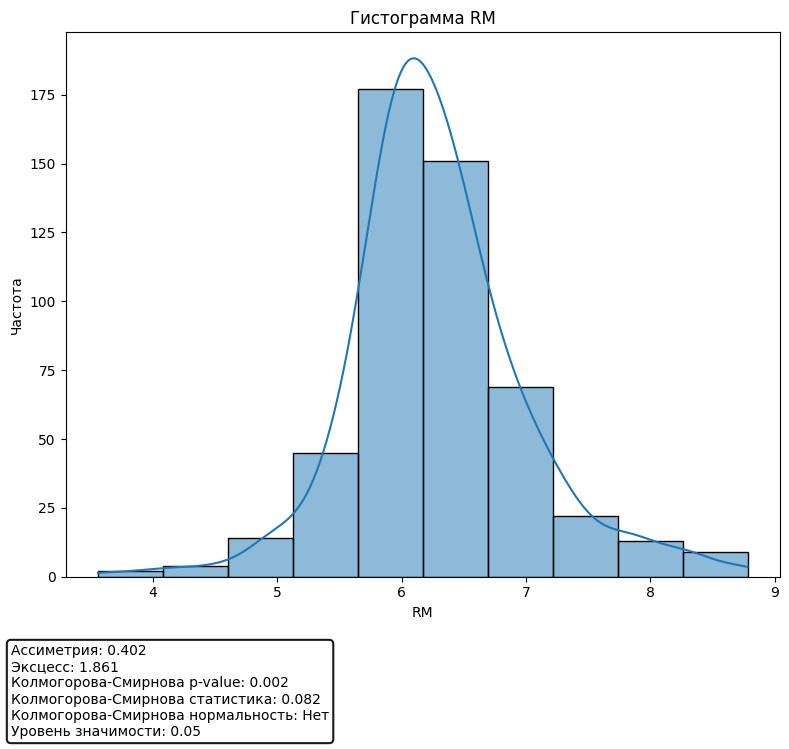

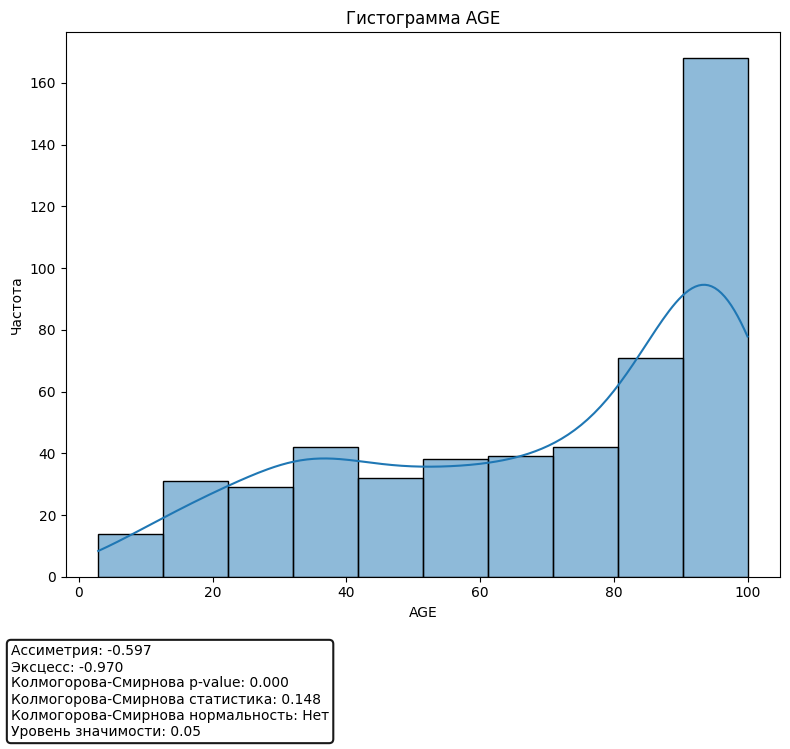

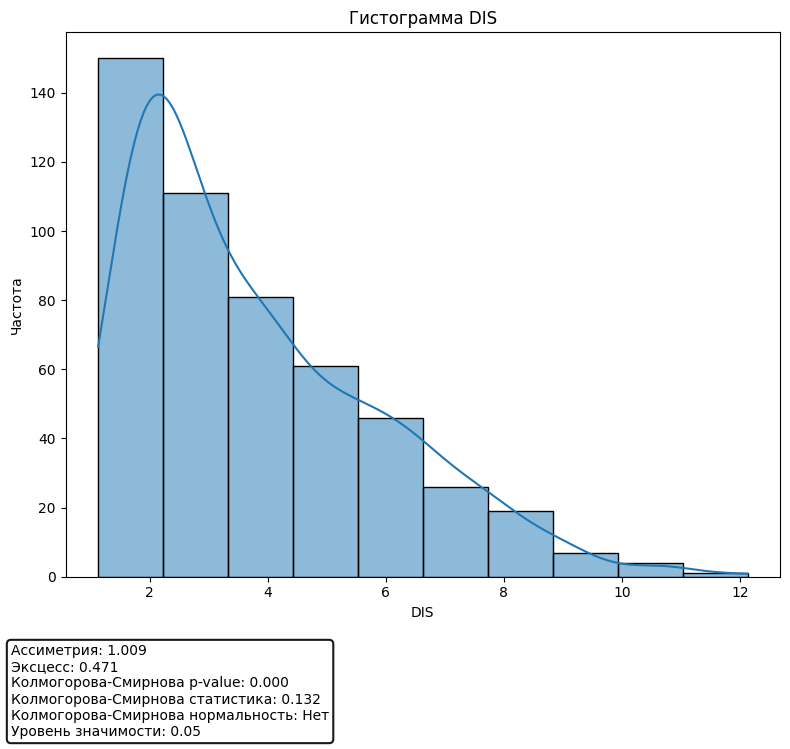

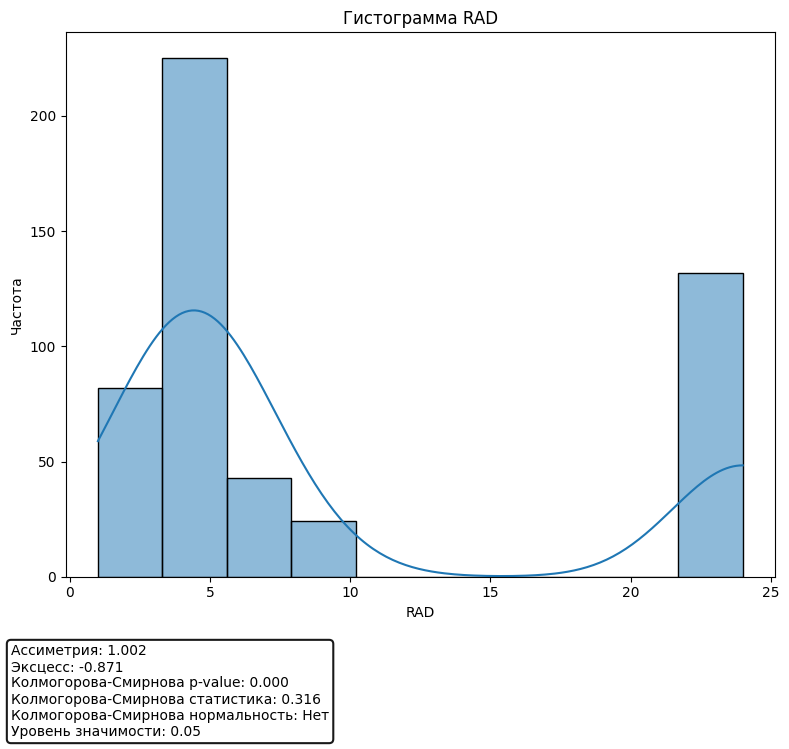

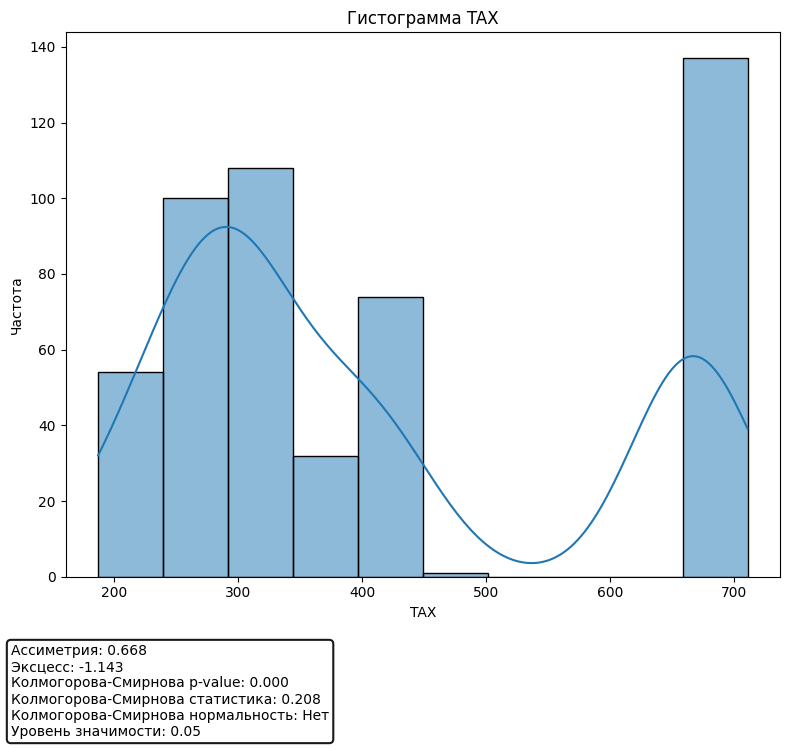

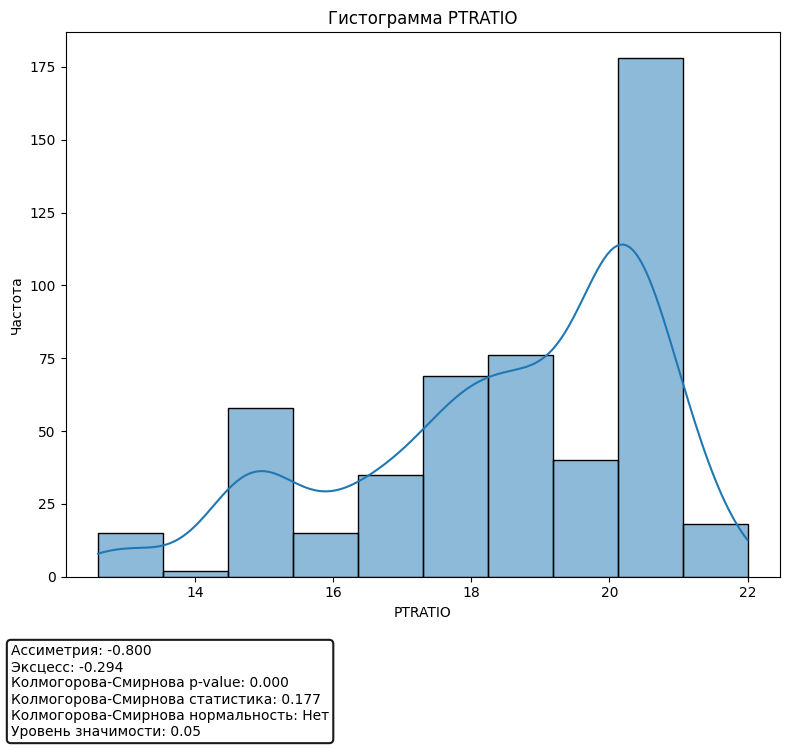

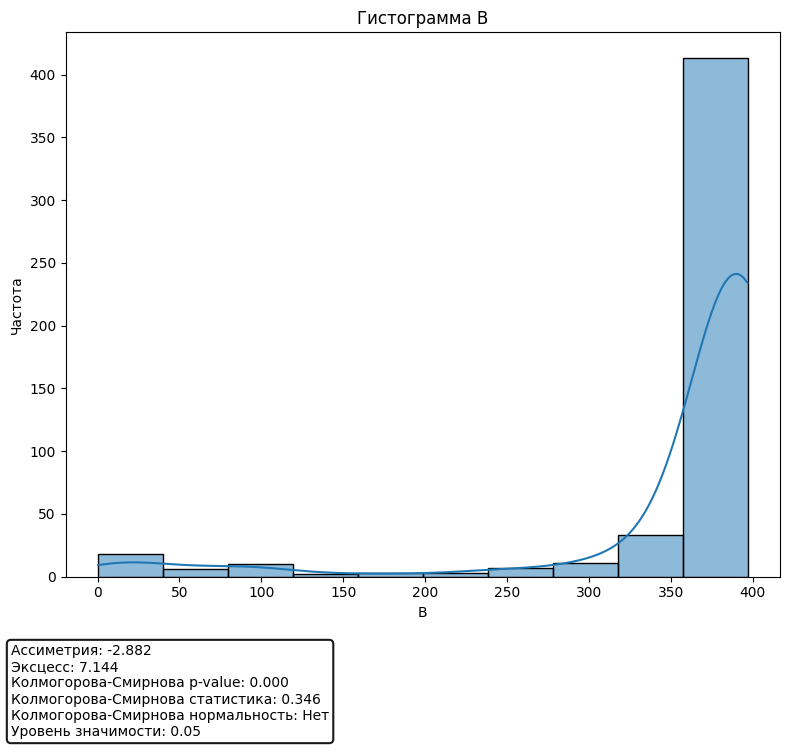

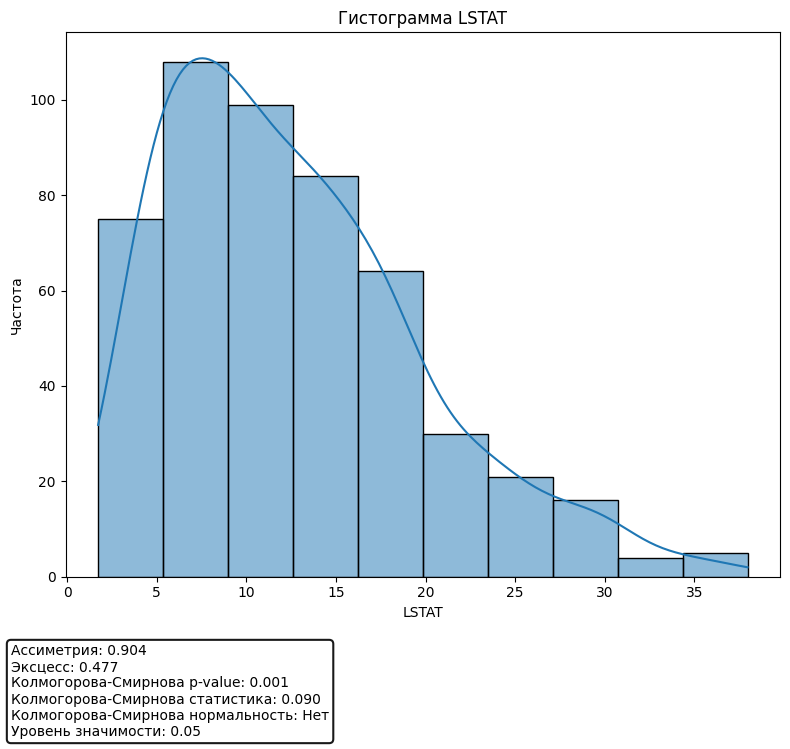

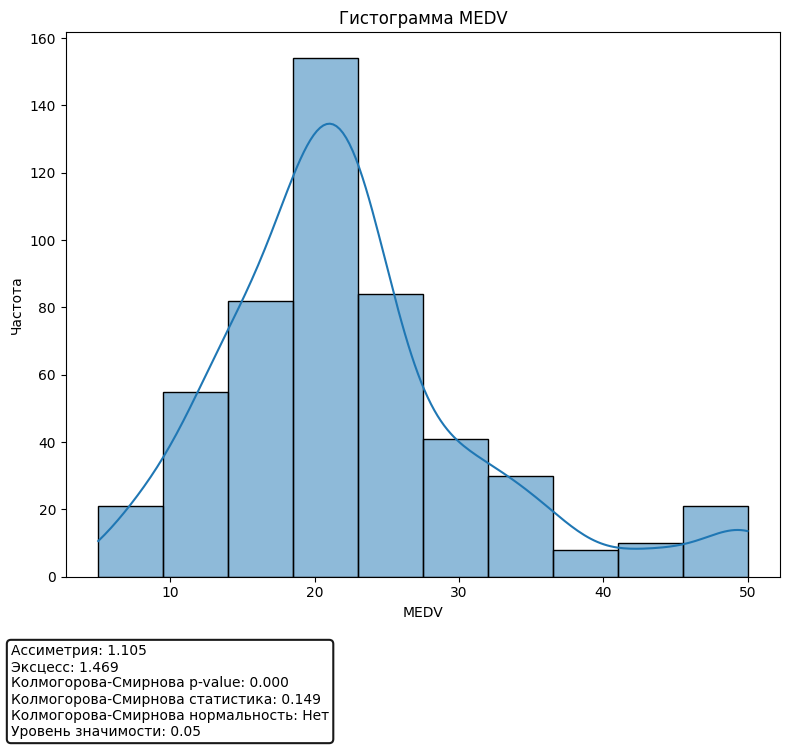

In [12]:
# Проверка распределений на нормальность
ALPHA = 0.05
for _, column in enumerate(df.columns):
    plt.figure(figsize=(8, 8))
    sns.histplot(df[column], kde=True, bins='sturges')

    ks_stat, ks_p_value = kstest(df[column], 'norm', args=(np.mean(df[column]), np.std(df[column])))

    legend = (
        f'Ассиметрия: {skew(df[column]):.3f}\n'
        f'Эксцесс: {kurtosis(df[column]):.3f}\n'
        f'Колмогорова-Смирнова p-value: {(ks_p_value):.3f}\n'
        f'Колмогорова-Смирнова статистика: {(ks_stat):.3f}\n'
        f'Колмогорова-Смирнова нормальность: {'Да' if ks_p_value >= ALPHA else 'Нет'}\n'
        f'Уровень значимости: {ALPHA}'
    )

    plt.figtext(
        0.02, 
        0.02, 
        legend, 
        ha='left', 
        va='bottom', 
        fontsize=10, 
        bbox=dict(
            boxstyle='round', 
            facecolor='white', 
            edgecolor='black',
            linewidth=1.5,
            alpha=0.9
        )
    )

    print(column)
    print(50 * '-')
    print(legend)
    print(50 * '=')
    print()

    plt.title(f'Гистограмма {column}')
    plt.xlabel(column)
    plt.ylabel('Частота')
    plt.tight_layout(rect=[0, 0.15, 1, 0.95])

# 3. Предобработка данных

In [13]:
# Предобработка данных
df.dropna(inplace=True) # Удаление пропущенных значений
df.drop(drop_columns, axis=1, errors='ignore', inplace=True) # Удаление столбцов

numeric_features = [col for col in df.select_dtypes(include=[np.number]).columns.tolist() 
                   if col != target]

# Нормализация факторов
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[numeric_features])

scaled_df = pd.DataFrame(scaled_features, columns=numeric_features, index=df.index)
scaled_df[target] = df[target]

print('Дискриптивный анализ после нормализации факторов:')
print(scaled_df.describe())

Дискриптивный анализ после нормализации факторов:
        CRIM     ZN  INDUS   CHAS    NOX     RM    AGE    DIS    RAD    TAX  \
count 506.00 506.00 506.00 506.00 506.00 506.00 506.00 506.00 506.00 506.00   
mean   -0.00   0.00   0.00  -0.00  -0.00  -0.00  -0.00  -0.00  -0.00   0.00   
std     1.00   1.00   1.00   1.00   1.00   1.00   1.00   1.00   1.00   1.00   
min    -0.42  -0.49  -1.56  -0.27  -1.47  -3.88  -2.34  -1.27  -0.98  -1.31   
25%    -0.41  -0.49  -0.87  -0.27  -0.91  -0.57  -0.84  -0.81  -0.64  -0.77   
50%    -0.39  -0.49  -0.21  -0.27  -0.14  -0.11   0.32  -0.28  -0.52  -0.46   
75%     0.01   0.05   1.02  -0.27   0.60   0.48   0.91   0.66   1.66   1.53   
max     9.93   3.80   2.42   3.67   2.73   3.56   1.12   3.96   1.66   1.80   

       PTRATIO      B  LSTAT   MEDV  
count   506.00 506.00 506.00 506.00  
mean     -0.00  -0.00  -0.00  22.53  
std       1.00   1.00   1.00   9.20  
min      -2.71  -3.91  -1.53   5.00  
25%      -0.49   0.21  -0.80  17.02  
50%       

# 4. Построение матрицы корреляции. Выводы о наличии мультиколлинеарности (расчет VIF-коэффициента)

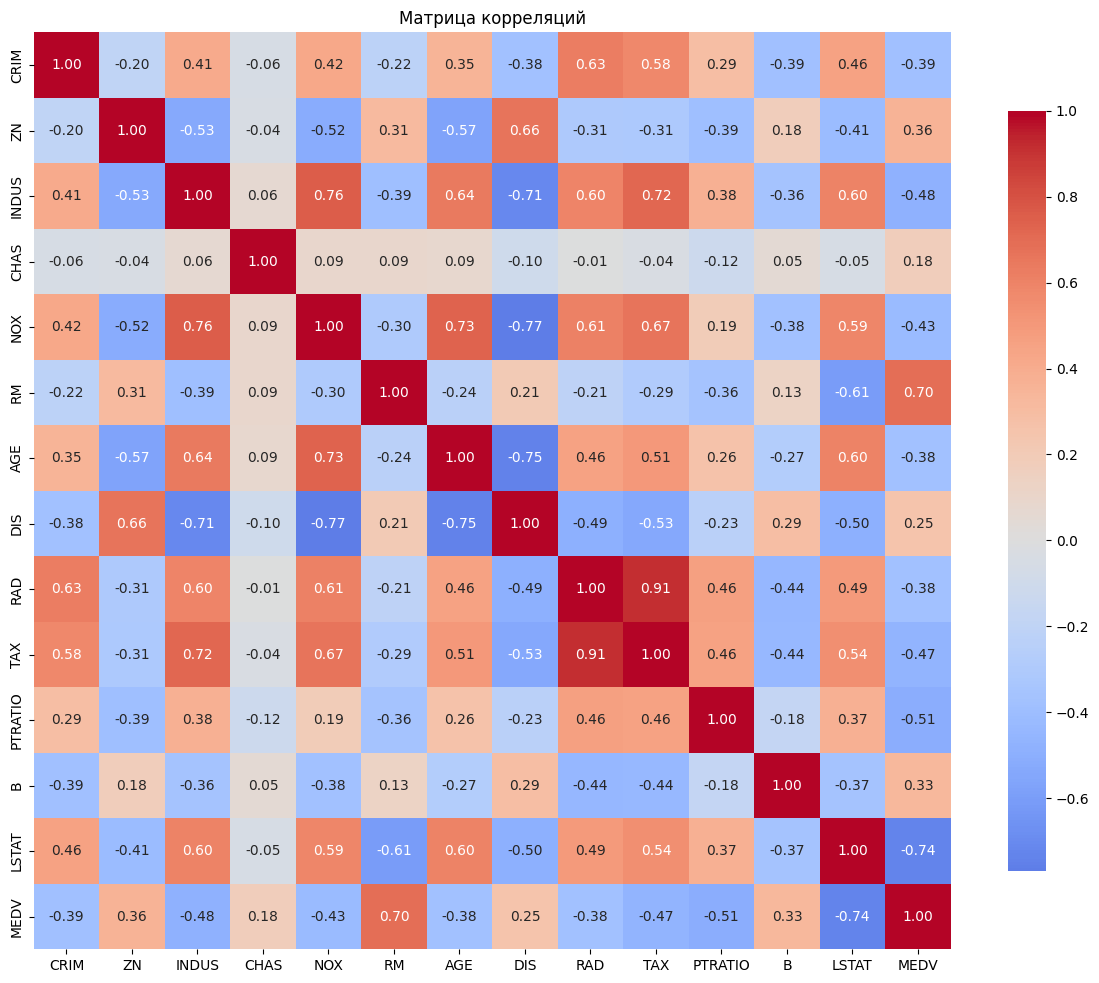

Коэффициенты корреляции для целевой переменной:
 MEDV       1.00
RM         0.70
ZN         0.36
B          0.33
DIS        0.25
CHAS       0.18
AGE       -0.38
RAD       -0.38
CRIM      -0.39
NOX       -0.43
TAX       -0.47
INDUS     -0.48
PTRATIO   -0.51
LSTAT     -0.74
Name: MEDV, dtype: float64


In [14]:
# Составление матрицы корреляций и тепловой карты
correlation_matrix = df.corr(method='pearson')

plt.figure(figsize=(12, 10))

sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True,
            cbar_kws={'shrink': .8})

plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

correlation_val = correlation_matrix[target].sort_values(ascending=False)
print('Коэффициенты корреляции для целевой переменной:\n',correlation_val)

Из анализа корреляции видно, что есть сильная зависимость целевой переменной MEDV от переменных: RM и LSTAT. 
Более сильная от переменных: NOX,TAX, INDUS, PTRATIO. 
Еще более слабая от переменных: ZN, B, DIS, CHAS, AGE, RAD, CRIM.   

От переменных RM, ZN, B, DIS, CHAS - прямая зависимость.
От переменных AGE, RAD, CRIM, NOX, TAX, INDUS, PTRATIO, LSTAT - обратная зависимость.      

In [15]:
# VIF анализ
vif_data = pd.DataFrame()
vif_data['Feature'] = scaled_df.columns
vif_data['VIF'] = [variance_inflation_factor(scaled_df.values, i) 
                   for i in range(len(df.columns))]

print('VIF коэффициенты:')
print(vif_data.sort_values('VIF', ascending=False))


crit_vif = vif_data[vif_data['VIF'] > 10]
if crit_vif.empty:
    print('Признаков с мультиколлинеарностью нет')
else:
    print('Признаки с мультиколлинеарностью:')
    for feature, vif in zip(crit_vif['Feature'], crit_vif['VIF']):
        print(f'  {feature}: VIF = {vif:.2f}')


VIF коэффициенты:
    Feature  VIF
9       TAX 9.02
8       RAD 7.50
4       NOX 4.40
2     INDUS 3.99
7       DIS 3.97
6       AGE 3.10
12    LSTAT 2.97
1        ZN 2.30
5        RM 1.95
10  PTRATIO 1.81
0      CRIM 1.79
11        B 1.35
13     MEDV 1.12
3      CHAS 1.07
Признаков с мультиколлинеарностью нет


VIF анализ показал, что сильной мультиколлинеарности нет, то есть ни у одного фактора VIF коэфициент не превышает 10. Однако данный коэфициент довольно критичен у факторов TAX и RAD.
VIF(TAX) = 9.02
VIF(RAD) = 7.50

Из чего можно сделать вывод, что дисперсия оценок коэффициентов регрессионной модели может получиться увеличенной, надежность модели может пострадать.

# 5. Построение регрессионных моделей

In [16]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split, KFold
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV

# Построение регрессионных моделей
X = df.drop(target, axis=1) 
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

# Используется при построеннии моделей через PCA
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Линейная регрессия
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr_train = lr_model.predict(X_train)
y_pred_lr_test = lr_model.predict(X_test)

lr_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_lr_train))
lr_r2_train = r2_score(y_train, y_pred_lr_train)
lr_mape_train = np.mean(np.abs((y_train - y_pred_lr_train) / y_train)) * 100

lr_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))
lr_r2_test = r2_score(y_test, y_pred_lr_test)
lr_mape_test = np.mean(np.abs((y_test - y_pred_lr_test) / y_test)) * 100

# Кроссвалидация линейной регрессии
lr_cv_rmse = np.sqrt(-cross_val_score(lr_model, X_train, y_train, cv=kfold, scoring='neg_mean_squared_error'))
lr_cv_r2 = cross_val_score(lr_model, X_train, y_train, cv=kfold, scoring='r2')
lr_cv_mape = -cross_val_score(lr_model, X_train, y_train, cv=kfold, scoring='neg_mean_absolute_percentage_error')

print('ЛИНЕЙНАЯ РЕГРЕССИЯ:')
print(f'TRAIN - RMSE: {lr_rmse_train:.4f}, R²: {lr_r2_train:.4f}, MAPE: {lr_mape_train:.2f}%')
print(f'TEST  - RMSE: {lr_rmse_test:.4f}, R²: {lr_r2_test:.4f}, MAPE: {lr_mape_test:.2f}%')
print(50 * '-')

print('КОЭФФИЦИЕНТЫ ЛИНЕЙНОЙ РЕГРЕССИИ:')
lr_coef_df = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент': lr_model.coef_,
    'Абсолютное значение': np.abs(lr_model.coef_)
}).sort_values('Абсолютное значение', ascending=False)

print(lr_coef_df.round(4), '\n')
print(f'Свободный член (intercept): {lr_model.intercept_:.4f}')
print(50 * '-')

print('КРОСС-ВАЛИДАЦИЯ ЛИНЕЙНОЙ РЕГРЕССИИ (5-fold):')
print(f'RMSE: {lr_cv_rmse.mean():.4f} (+/- {lr_cv_rmse.std() * 2:.4f})')
print(f'R²:   {lr_cv_r2.mean():.4f} (+/- {lr_cv_r2.std() * 2:.4f})')
print(f'MAPE: {lr_cv_mape.mean() * 100:.2f}% (+/- {lr_cv_mape.std() * 2 * 100:.2f}%)')
print(50 * '=')


# Гребниевая регрессия
alphas = np.logspace(-3, 3, 50)
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)

ridge_model = Ridge(alpha=ridge_cv.alpha_)
ridge_model.fit(X_train, y_train)

y_pred_ridge_train = ridge_model.predict(X_train)
y_pred_ridge_test = ridge_model.predict(X_test)

ridge_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_ridge_train))
ridge_r2_train = r2_score(y_train, y_pred_ridge_train)
ridge_mape_train = np.mean(np.abs((y_train - y_pred_ridge_train) / y_train)) * 100

ridge_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
ridge_r2_test = r2_score(y_test, y_pred_ridge_test)
ridge_mape_test = np.mean(np.abs((y_test - y_pred_ridge_test) / y_test)) * 100

# Кросс-валидация гребниевой регрессии
ridge_cv_rmse = np.sqrt(-cross_val_score(ridge_model, X_train, y_train, cv=kfold, scoring='neg_mean_squared_error'))
ridge_cv_r2 = cross_val_score(ridge_model, X_train, y_train, cv=kfold, scoring='r2')
ridge_cv_mape = -cross_val_score(ridge_model, X_train, y_train, cv=kfold, scoring='neg_mean_absolute_percentage_error')

print('ГРЕБНЕВАЯ РЕГРЕССИЯ:')
print(f'Оптимальный alpha для Ridge: {ridge_cv.alpha_:.4f}')
print(f'TRAIN - RMSE: {ridge_rmse_train:.4f}, R²: {ridge_r2_train:.4f}, MAPE: {ridge_mape_train:.2f}%')
print(f'TEST  - RMSE: {ridge_rmse_test:.4f}, R²: {ridge_r2_test:.4f}, MAPE: {ridge_mape_test:.2f}%')
print(50 * '-')

print('КОЭФФИЦИЕНТЫ ГРЕБНЕВОЙ РЕГРЕССИИ:')
ridge_coef_df = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент': ridge_model.coef_,
    'Абсолютное значение': np.abs(ridge_model.coef_)
}).sort_values('Абсолютное значение', ascending=False)

print(ridge_coef_df.round(4), '\n')
print(f'Свободный член (intercept): {ridge_model.intercept_:.4f}')
print(50 * '-')

print('КРОСС-ВАЛИДАЦИЯ ГРЕБНЕВОЙ РЕГРЕССИИ (5-fold):')
print(f'RMSE: {ridge_cv_rmse.mean():.4f} (+/- {ridge_cv_rmse.std() * 2:.4f})')
print(f'R²:   {ridge_cv_r2.mean():.4f} (+/- {ridge_cv_r2.std() * 2:.4f})')
print(f'MAPE: {ridge_cv_mape.mean() * 100:.2f}% (+/- {ridge_cv_mape.std() * 2 * 100:.2f}%)')
print(50 * '=')


# Таблица сравнения моделей
compare_table = pd.DataFrame({
    'Метрика': ['RMSE', 'R²', 'MAPE (%)'],
    'Линейная регрессия': [lr_rmse_test, lr_r2_test, lr_mape_test],
    'Гребневая регрессия': [ridge_rmse_test, ridge_r2_test, ridge_mape_test]
})

print('Сравнение построенных моделей:')
print(compare_table)

ЛИНЕЙНАЯ РЕГРЕССИЯ:
TRAIN - RMSE: 4.6520, R²: 0.7509, MAPE: 16.57%
TEST  - RMSE: 4.9286, R²: 0.6688, MAPE: 16.87%
--------------------------------------------------
КОЭФФИЦИЕНТЫ ЛИНЕЙНОЙ РЕГРЕССИИ:
    Признак  Коэффициент  Абсолютное значение
4       NOX       -17.20                17.20
5        RM         4.44                 4.44
3      CHAS         2.78                 2.78
7       DIS        -1.45                 1.45
10  PTRATIO        -0.92                 0.92
12    LSTAT        -0.51                 0.51
8       RAD         0.26                 0.26
0      CRIM        -0.11                 0.11
2     INDUS         0.04                 0.04
1        ZN         0.03                 0.03
11        B         0.01                 0.01
9       TAX        -0.01                 0.01
6       AGE        -0.01                 0.01 

Свободный член (intercept): 30.2468
--------------------------------------------------
КРОСС-ВАЛИДАЦИЯ ЛИНЕЙНОЙ РЕГРЕССИИ (5-fold):
RMSE: 4.8663 (+/- 1.5971

Параметры построенных линейной и гребневой регрессионных моделей, а также таблицу сравнения, можно увидеть в выводе.
При сравнении выяснилось, что линейная и гребневая модели одинакого эффективны на данном датасете.

Обе модели достаточно качественны.
Коэффициент детерминации R² = 0.67, что говорит о том, что порядка 67% изменении целевой переменной объясняется моделями.
Среднеквадратичная ошибка RMSE = 4.93 
Средняя абсолютная ошибка (%) MAPE (%) = 16.87%

Объясненная дисперсия по компонентам:
PC1: 0.471 (0.471 кумулятивно)

PC2: 0.110 (0.582 кумулятивно)

PC3: 0.096 (0.677 кумулятивно)

PC4: 0.066 (0.743 кумулятивно)

PC5: 0.064 (0.807 кумулятивно)

PC6: 0.051 (0.858 кумулятивно)

PC7: 0.041 (0.899 кумулятивно)

PC8: 0.030 (0.930 кумулятивно)

PC9: 0.021 (0.951 кумулятивно)

PC10: 0.017 (0.968 кумулятивно)

PC11: 0.014 (0.982 кумулятивно)

PC12: 0.013 (0.995 кумулятивно)

PC13: 0.005 (1.000 кумулятивно)

Суммарная объяснённая дисперсия 1.000


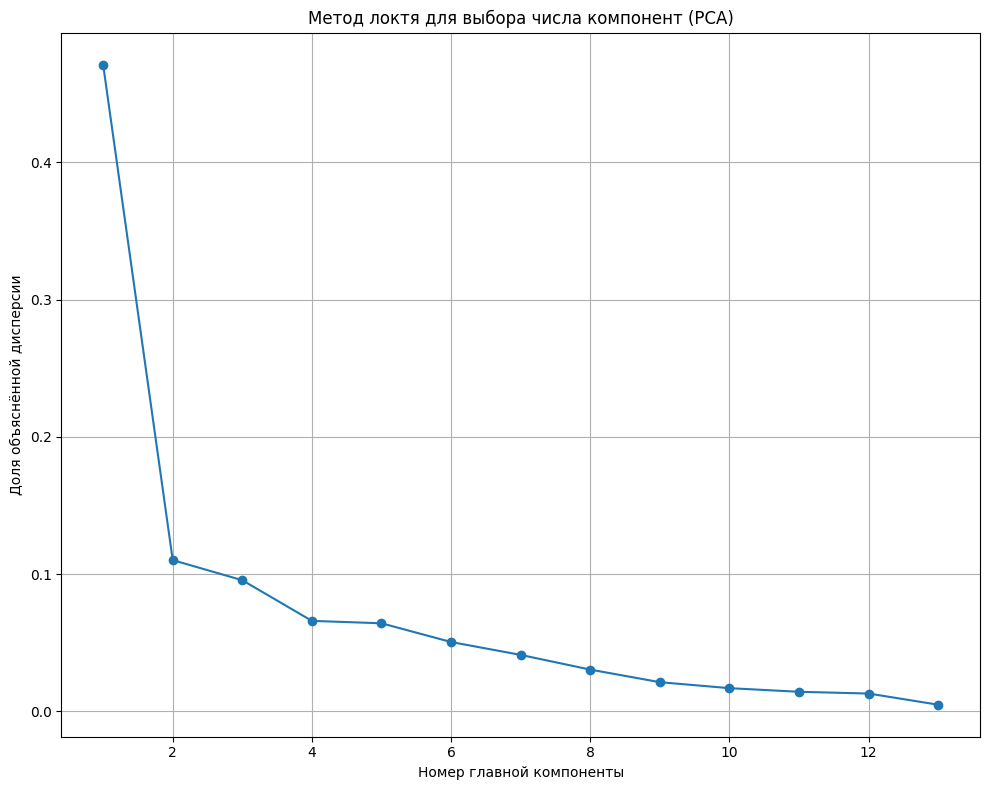

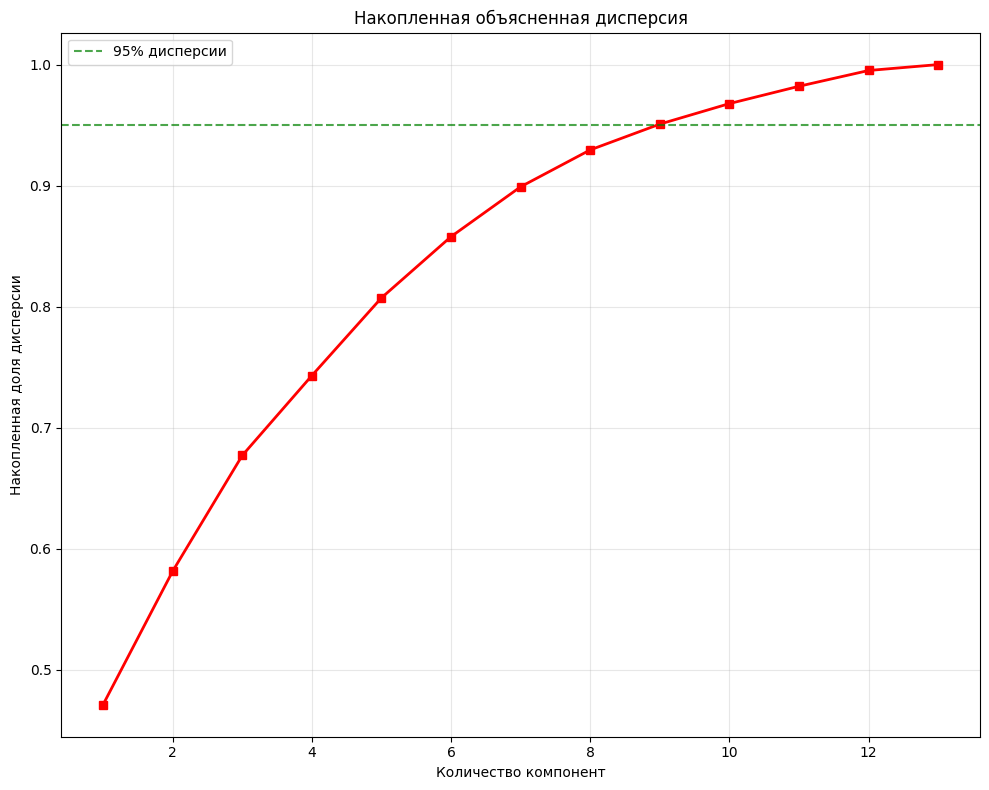

In [17]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print('Объясненная дисперсия по компонентам:')
for i, (variance, cum_var) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f'PC{i+1}: {variance:.3f} ({cum_var:.3f} кумулятивно)\n')
print(f'Суммарная объяснённая дисперсия {cumulative_variance[-1]:.3f}')

# График метода 'Локтя'
plt.figure(figsize=(10, 8))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.title('Метод локтя для выбора числа компонент (PCA)')
plt.xlabel('Номер главной компоненты')
plt.ylabel('Доля объяснённой дисперсии')
plt.grid(True)
plt.tight_layout()
plt.show()

# График накопленной объясненной дисперсии
plt.figure(figsize=(10, 8))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='s', color='red', linewidth=2, markersize=6)
plt.axhline(y=0.95, color='green', linestyle='--', alpha=0.7, label='95% дисперсии')
plt.title('Накопленная объясненная дисперсия')
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная доля дисперсии')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
    

Вычисление PCA показало, что 9 компонентов охватывают не менее 95% общей дисперсии

In [18]:
# Повторное построение моделей регрессии, но уже через PCA
n_components = np.argmax(cumulative_variance >= 0.95) + 1

pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)

y_pred_lr_pca_train = lr_pca.predict(X_train_pca)
y_pred_lr_pca_test = lr_pca.predict(X_test_pca)

lr_pca_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_lr_pca_train))
lr_pca_r2_train = r2_score(y_train, y_pred_lr_pca_train)
lr_pca_mape_train = np.mean(np.abs((y_train - y_pred_lr_pca_train) / y_train)) * 100

lr_pca_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_lr_pca_test))
lr_pca_r2_test = r2_score(y_test, y_pred_lr_pca_test)
lr_pca_mape_test = np.mean(np.abs((y_test - y_pred_lr_pca_test) / y_test)) * 100

print('ЛИНЕЙНАЯ РЕГРЕССИЯ НА PCA:')
print(f'TRAIN - RMSE: {lr_pca_rmse_train:.4f}, R²: {lr_pca_r2_train:.4f}, MAPE: {lr_pca_mape_train:.2f}%')
print(f'TEST  - RMSE: {lr_pca_rmse_test:.4f}, R²: {lr_pca_r2_test:.4f}, MAPE: {lr_pca_mape_test:.2f}%')
print(50 * '-')

print('КОЭФФИЦИЕНТЫ ЛИНЕЙНОЙ РЕГРЕССИИ НА PCA:')
lr_pca_coef_df = pd.DataFrame({
    'Компонента': [f'PC{i+1}' for i in range(n_components)],
    'Коэффициент': lr_pca.coef_,
    'Абсолютное значение': np.abs(lr_pca.coef_)
}).sort_values('Абсолютное значение', ascending=False)

print(lr_pca_coef_df.round(4), '\n')
print(f'Свободный член (intercept): {lr_pca.intercept_:.4f}')
print(50 * '-')

# Кросс-валидация линейной регрессии на PCA
lr_pca_cv_rmse = np.sqrt(-cross_val_score(lr_pca, X_train_pca, y_train, cv=kfold, scoring='neg_mean_squared_error'))
lr_pca_cv_r2 = cross_val_score(lr_pca, X_train_pca, y_train, cv=kfold, scoring='r2')
lr_pca_cv_mape = -cross_val_score(lr_pca, X_train_pca, y_train, cv=kfold, scoring='neg_mean_absolute_percentage_error')

print('КРОСС-ВАЛИДАЦИЯ ЛИНЕЙНОЙ РЕГРЕССИИ НА PCA (5-fold):')
print(f'RMSE: {lr_pca_cv_rmse.mean():.4f} (+/- {lr_pca_cv_rmse.std() * 2:.4f})')
print(f'R²:   {lr_pca_cv_r2.mean():.4f} (+/- {lr_pca_cv_r2.std() * 2:.4f})')
print(f'MAPE: {lr_pca_cv_mape.mean() * 100:.2f}% (+/- {lr_pca_cv_mape.std() * 2 * 100:.2f}%)')
print(50 * '=')


# Гребневая регрессия на PCA
ridge_pca = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_squared_error')
ridge_pca.fit(X_train_pca, y_train)

y_pred_ridge_pca_train = ridge_pca.predict(X_train_pca)
y_pred_ridge_pca_test = ridge_pca.predict(X_test_pca)

ridge_pca_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_ridge_pca_train))
ridge_pca_r2_train = r2_score(y_train, y_pred_ridge_pca_train)
ridge_pca_mape_train = np.mean(np.abs((y_train - y_pred_ridge_pca_train) / y_train)) * 100

ridge_pca_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_ridge_pca_test))
ridge_pca_r2_test = r2_score(y_test, y_pred_ridge_pca_test)
ridge_pca_mape_test = np.mean(np.abs((y_test - y_pred_ridge_pca_test) / y_test)) * 100

print('ГРЕБНЕВАЯ РЕГРЕССИЯ НА PCA:')
print(f'Оптимальный alpha для Ridge: {ridge_pca.alpha_:.4f}')
print(f'TRAIN - RMSE: {ridge_pca_rmse_train:.4f}, R²: {ridge_pca_r2_train:.4f}, MAPE: {ridge_pca_mape_train:.2f}%')
print(f'TEST  - RMSE: {ridge_pca_rmse_test:.4f}, R²: {ridge_pca_r2_test:.4f}, MAPE: {ridge_pca_mape_test:.2f}%')
print(50 * '-')

print('КОЭФФИЦИЕНТЫ ГРЕБНЕВОЙ РЕГРЕССИИ НА PCA:')
ridge_pca_coef_df = pd.DataFrame({
    'Компонента': [f'PC{i+1}' for i in range(n_components)],
    'Коэффициент': ridge_pca.coef_,
    'Абсолютное значение': np.abs(ridge_pca.coef_)
}).sort_values('Абсолютное значение', ascending=False)

print(ridge_pca_coef_df.round(4), '\n')
print(f'Свободный член (intercept): {ridge_pca.intercept_:.4f}')
print(50 * '-')

# Кросс-валидация гребневой регрессии на PCA
ridge_pca_cv_rmse = np.sqrt(-cross_val_score(ridge_pca, X_train_pca, y_train, cv=kfold, scoring='neg_mean_squared_error'))
ridge_pca_cv_r2 = cross_val_score(ridge_pca, X_train_pca, y_train, cv=kfold, scoring='r2')
ridge_pca_cv_mape = -cross_val_score(ridge_pca, X_train_pca, y_train, cv=kfold, scoring='neg_mean_absolute_percentage_error')

print('КРОСС-ВАЛИДАЦИЯ ГРЕБНЕВОЙ РЕГРЕССИИ НА PCA (5-fold):')
print(f'RMSE: {ridge_pca_cv_rmse.mean():.4f} (+/- {ridge_pca_cv_rmse.std() * 2:.4f})')
print(f'R²:   {ridge_pca_cv_r2.mean():.4f} (+/- {ridge_pca_cv_r2.std() * 2:.4f})')
print(f'MAPE: {ridge_pca_cv_mape.mean() * 100:.2f}% (+/- {ridge_pca_cv_mape.std() * 2 * 100:.2f}%)')
print(50 * '=')


print('СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ:')
comparison_all = pd.DataFrame({
    'Модель': ['Linear (исходные)', 'Ridge (исходные)', 'Linear (PCA)', 'Ridge (PCA)'],
    'RMSE_test': [lr_rmse_test, ridge_rmse_test, lr_pca_rmse_test, ridge_pca_rmse_test],
    'R2_test': [lr_r2_test, ridge_r2_test, lr_pca_r2_test, ridge_pca_r2_test],
    'MAPE_test': [lr_mape_test, ridge_mape_test, lr_pca_mape_test, ridge_pca_mape_test],
    'Признаков': [X.shape[1], X.shape[1], n_components, n_components]
})

print(comparison_all.round(4))

ЛИНЕЙНАЯ РЕГРЕССИЯ НА PCA:
TRAIN - RMSE: 4.8997, R²: 0.7237, MAPE: 16.94%
TEST  - RMSE: 5.6296, R²: 0.5678, MAPE: 22.59%
--------------------------------------------------
КОЭФФИЦИЕНТЫ ЛИНЕЙНОЙ РЕГРЕССИИ НА PCA:
  Компонента  Коэффициент  Абсолютное значение
2        PC3         3.30                 3.30
1        PC2         2.74                 2.74
4        PC5         2.48                 2.48
0        PC1        -2.27                 2.27
5        PC6         1.12                 1.12
7        PC8        -1.10                 1.10
6        PC7        -0.71                 0.71
3        PC4         0.33                 0.33
8        PC9         0.24                 0.24 

Свободный член (intercept): 22.7965
--------------------------------------------------
КРОСС-ВАЛИДАЦИЯ ЛИНЕЙНОЙ РЕГРЕССИИ НА PCA (5-fold):
RMSE: 5.0707 (+/- 1.8344)
R²:   0.6935 (+/- 0.1901)
MAPE: 17.56% (+/- 2.47%)
ГРЕБНЕВАЯ РЕГРЕССИЯ НА PCA:
Оптимальный alpha для Ridge: 19.3070
TRAIN - RMSE: 4.9056, R²: 0.7230, M

Были повторно построены регрессионные модели на PCA и произведено сравнение всех моделей: на исходных данных и на PCA.

Модели, построенные на PCA оказались менее эффективными, чем модели, построенные на исходных данных.

Линейная модель на исходных данных имеет те же показатели, что и гребневая R² = 0.67
Линейная модель на PCA имеет R² = 0.57
Гребневая модель на PCA имеет R² = 0.58

Можно сказать, что относительно друг друга при переходе на PCA линейная и гребневая модель не изменили своей эффективности.